<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.00000

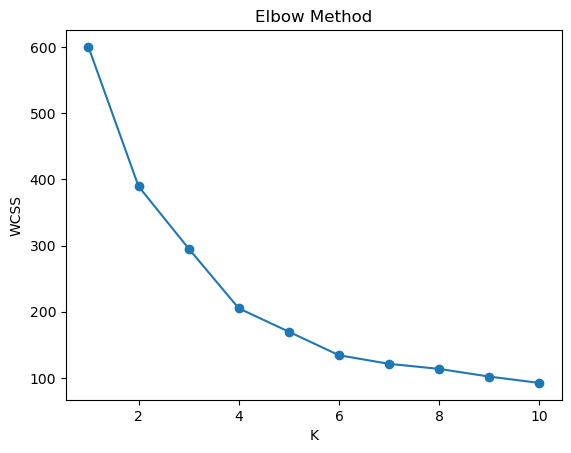

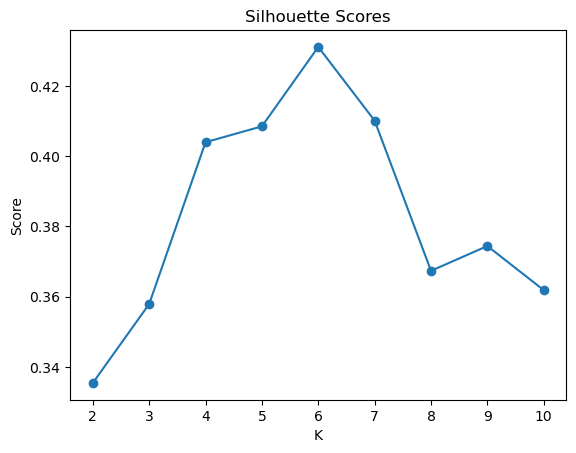

[[ 1.17882975 -0.49388609 -0.32971553]
 [-0.42880597  0.97484722  1.21608539]
 [-0.93876351 -1.31473131  0.95680216]
 [-0.86957306 -0.23851652 -0.36060916]
 [ 0.39737911  1.11508909 -1.23126963]]


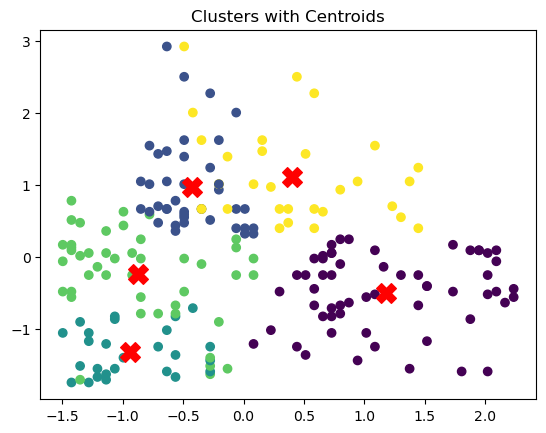

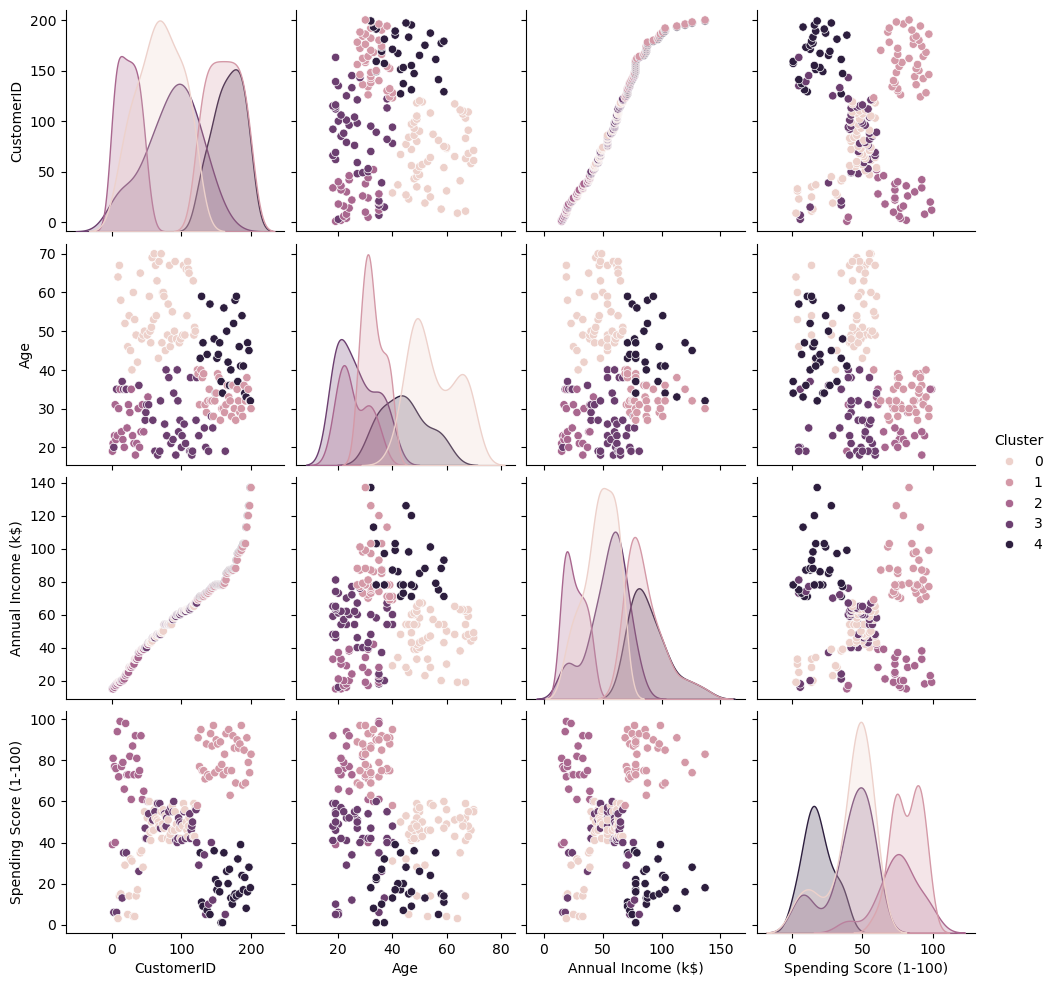

In [21]:
#Task01
import os
import warnings

os.environ["OMP_NUM_THREADS"] = "1"
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Preview
df.head()
print(df.info())
print(df.isnull().sum())
print(df.describe())
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
wcss = []

for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()
sil_scores = []

for i in range(2, 11):
    km = KMeans(n_clusters=i, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.plot(range(2, 11), sil_scores, marker='o')
plt.title("Silhouette Scores")
plt.xlabel("K")
plt.ylabel("Score")
plt.show()
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

centroids = kmeans.cluster_centers_
print(centroids)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=df['Cluster'])
plt.scatter(centroids[:,0], centroids[:,1], c='red', s=200, marker='X')
plt.title("Clusters with Centroids")
plt.show()
sns.pairplot(df, hue='Cluster')
plt.show()

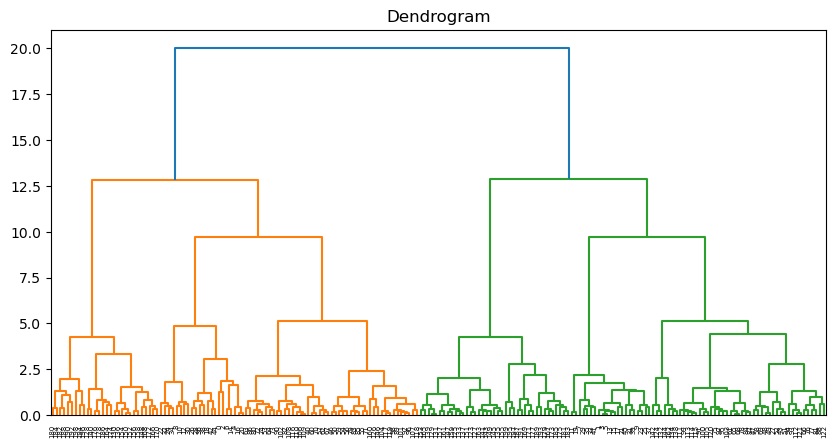

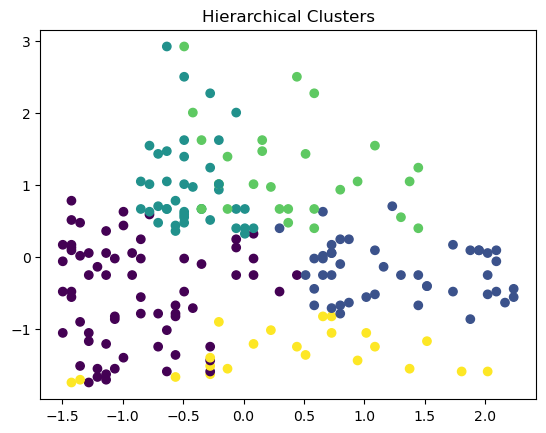

Text(0.5, 1.0, 'Hierarchical')

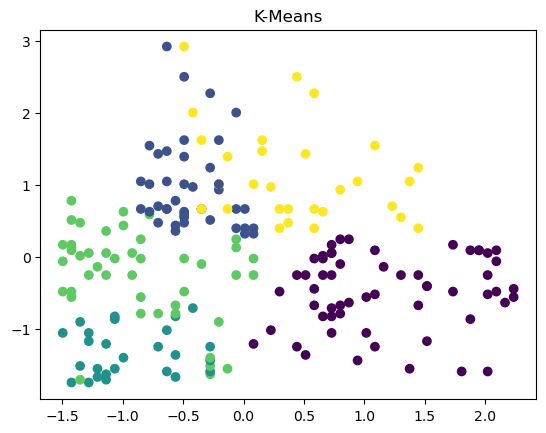

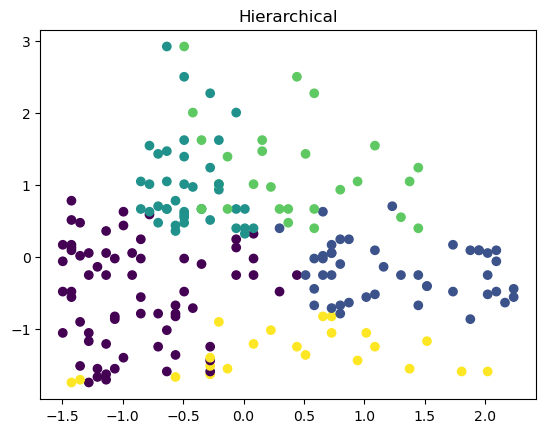

In [22]:
#TASK 02
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(10,5))
sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title("Dendrogram")
plt.show()
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=5)
df['HC_Cluster'] = hc.fit_predict(X_scaled)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=df['HC_Cluster'])
plt.title("Hierarchical Clusters")
plt.show()
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=df['Cluster'])
plt.title("K-Means")

plt.figure()
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=df['HC_Cluster'])
plt.title("Hierarchical")

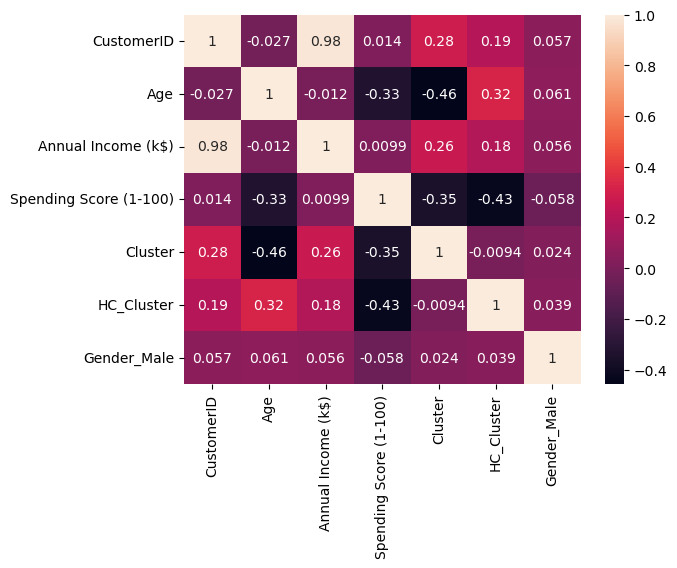

Without Encoding: 0.40846873777345605
With Encoding: 0.2719102346618833


In [23]:
#TASK 03
df_encoded = pd.get_dummies(df, columns=['Gender'], drop_first=True)
X_new = df_encoded[['Age','Annual Income (k$)','Spending Score (1-100)','Gender_Male']]

X_scaled_new = scaler.fit_transform(X_new)
kmeans2 = KMeans(n_clusters=5, random_state=42)
df['Cluster_Encoded'] = kmeans2.fit_predict(X_scaled_new)
sns.heatmap(df_encoded.corr(), annot=True)
plt.show()
print("Without Encoding:", silhouette_score(X_scaled, df['Cluster']))
print("With Encoding:", silhouette_score(X_scaled_new, df['Cluster_Encoded']))


In [24]:
#TASK 04
k_raw = KMeans(n_clusters=5).fit(X)
k_scaled = KMeans(n_clusters=5).fit(X_scaled)

print("Raw inertia:", k_raw.inertia_)
print("Scaled inertia:", k_scaled.inertia_)
print(silhouette_score(X, k_raw.labels_))
print(silhouette_score(X_scaled, k_scaled.labels_))

Raw inertia: 75378.76464074483
Scaled inertia: 168.82367051293215
0.44446409171786105
0.4113312881915614


E:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
E:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Before: [[43.08860759 55.29113924 49.56962025]
 [40.66666667 87.75       17.58333333]
 [32.69230769 86.53846154 82.12820513]
 [25.52173913 26.30434783 78.56521739]
 [45.2173913  26.30434783 20.91304348]]
After: [[24.8        41.46       63.7       ]
 [40.62162162 85.64864865 18.64864865]
 [44.31818182 25.77272727 20.27272727]
 [32.76315789 85.21052632 82.10526316]
 [53.82352941 54.7254902  48.98039216]]


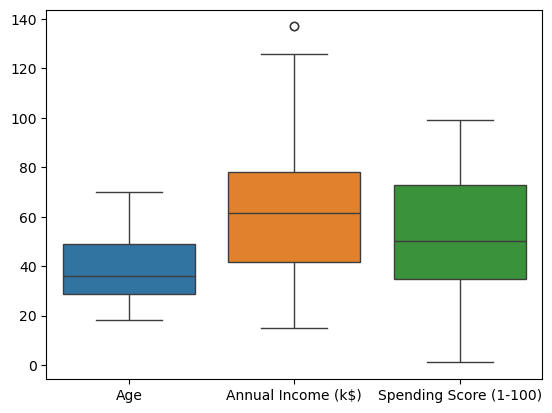

In [19]:
#TASK 05
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

outliers = ((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR)))
X_clean = X[~outliers.any(axis=1)]
k_before = KMeans(n_clusters=5).fit(X)
k_after = KMeans(n_clusters=5).fit(X_clean)

print("Before:", k_before.cluster_centers_)
print("After:", k_after.cluster_centers_)
sns.boxplot(data=X)
plt.show()

E:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


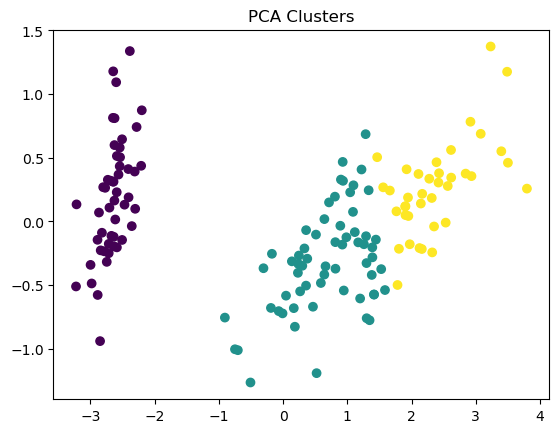

[[50  0  0]
 [ 0 48  2]
 [ 0 14 36]]


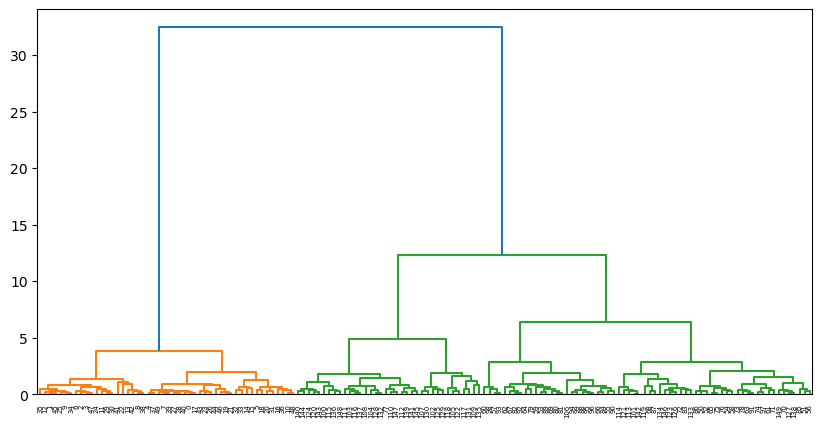

In [20]:
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris.data
y_true = iris.target
k_iris = KMeans(n_clusters=3)
labels = k_iris.fit_predict(X_iris)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_iris)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.title("PCA Clusters")
plt.show()
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_true, labels))
plt.figure(figsize=(10,5))
sch.dendrogram(sch.linkage(X_iris, method='ward'))
plt.show()
